# Review High-Confidence Outliers

This notebook loads the baseline high-confidence outlier CSV and prints a compact review summary for manual auditing.

In [1]:
from pathlib import Path
import pandas as pd

def find_task_root() -> Path:
    search_roots = (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for candidate in search_roots:
        if (candidate / 'data').exists() and (candidate / 'scripts').exists() and (candidate / 'src').exists():
            return candidate
        task_root = candidate / 'Task-1'
        if (task_root / 'data').exists() and (task_root / 'scripts').exists() and (task_root / 'src').exists():
            return task_root
    raise FileNotFoundError('Could not locate the Task-1 project root.')

repo_root = find_task_root()
csv_path = repo_root / 'grouped_audit' / 'manual_label_audit_artist.csv'
df = pd.read_csv(csv_path)

print(f'CSV path: {csv_path}')
print(f'Rows: {len(df)}')
print(f'Columns: {len(df.columns)}')
print('Incorrect task counts:')
print(df['incorrect_tasks'].fillna('none').value_counts().to_string())

CSV path: /Users/Lenovo/Desktop/sem 6/Gsoc_HumanAi/grouped_audit/manual_label_audit_artist.csv
Rows: 6
Columns: 13
Incorrect task counts:
incorrect_tasks
artist    6


In [2]:
review_columns= [col for col in df.columns if col.startswith('reviewer')]
print(f'Reviewer columns: {review_columns}')

Reviewer columns: []


In [3]:
review_columns = [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'style_true_name', 'style_pred_name',
    'genre_true_name', 'genre_pred_name',
    'artist_true_name', 'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]

top20 = df.loc[:19, review_columns].copy()
top20.index = top20.index + 1
top20

,rank_in_group,image_path,incorrect_tasks,style_true_name,style_pred_name,genre_true_name,genre_pred_name,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Romanticism/gustave-dore_a-souvenir-from-scotl...,artist,Romanticism,Romanticism,landscape,landscape,Gustave_Dore,Ivan_Aivazovsky,0.992607,model_error,Gustave_Dore,Current artist attribution remains more plausi...
2,2,Realism/vincent-van-gogh_autumn-landscape-with...,artist,Realism,Realism,landscape,landscape,Vincent_van_Gogh,Ivan_Shishkin,0.991835,model_error,Vincent_van_Gogh,Current artist attribution remains more plausi...
3,3,Realism/ilya-repin_portrait-of-b-a-kaminka-190...,artist,Realism,Realism,portrait,portrait,Ilya_Repin,Boris_Kustodiev,0.980938,model_error,Ilya_Repin,Current artist attribution remains more plausi...
4,4,Impressionism/claude-monet_amsterdam-in-the-sn...,artist,Impressionism,Impressionism,cityscape,cityscape,Claude_Monet,Eugene_Boudin,0.974637,model_error,Claude_Monet,Current artist attribution remains more plausi...
5,5,Impressionism/camille-pissarro_le-boulevard-de...,artist,Impressionism,Impressionism,cityscape,cityscape,Camille_Pissarro,Claude_Monet,0.973025,model_error,Camille_Pissarro,Current artist attribution remains more plausi...
6,6,Cubism/pablo-picasso_still-life-in-front-of-a-...,artist,Cubism,Cubism,still_life,still_life,Pablo_Picasso,Salvador_Dali,0.972587,model_error,Pablo_Picasso,Current artist attribution remains more plausi...


In [4]:
artist_only = df[df['incorrect_tasks'] == 'artist'][[
    'rank_in_group',
    'image_path',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict', 'suggested_label', 'notes',
]].head(20).copy()
artist_only.index = artist_only.index + 1
artist_only

,rank_in_group,image_path,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
1,1,Romanticism/gustave-dore_a-souvenir-from-scotl...,Gustave_Dore,Ivan_Aivazovsky,0.992607,model_error,Gustave_Dore,Current artist attribution remains more plausi...
2,2,Realism/vincent-van-gogh_autumn-landscape-with...,Vincent_van_Gogh,Ivan_Shishkin,0.991835,model_error,Vincent_van_Gogh,Current artist attribution remains more plausi...
3,3,Realism/ilya-repin_portrait-of-b-a-kaminka-190...,Ilya_Repin,Boris_Kustodiev,0.980938,model_error,Ilya_Repin,Current artist attribution remains more plausi...
4,4,Impressionism/claude-monet_amsterdam-in-the-sn...,Claude_Monet,Eugene_Boudin,0.974637,model_error,Claude_Monet,Current artist attribution remains more plausi...
5,5,Impressionism/camille-pissarro_le-boulevard-de...,Camille_Pissarro,Claude_Monet,0.973025,model_error,Camille_Pissarro,Current artist attribution remains more plausi...
6,6,Cubism/pablo-picasso_still-life-in-front-of-a-...,Pablo_Picasso,Salvador_Dali,0.972587,model_error,Pablo_Picasso,Current artist attribution remains more plausi...


thumbnail,rank_in_group,image_path,incorrect_tasks,artist_true_name,artist_pred_name,mean_confidence,verdict,suggested_label,notes
,1,Romanticism/gustave-dore_a-souvenir-from-scotland-1879.jpg,artist,Gustave_Dore,Ivan_Aivazovsky,0.992607,model_error,Gustave_Dore,Current artist attribution remains more plausible than the predicted artist.
,2,Realism/vincent-van-gogh_autumn-landscape-with-four-trees-1885(1).jpg,artist,Vincent_van_Gogh,Ivan_Shishkin,0.991835,model_error,Vincent_van_Gogh,Current artist attribution remains more plausible than the predicted artist.
,3,Realism/ilya-repin_portrait-of-b-a-kaminka-1908.jpg,artist,Ilya_Repin,Boris_Kustodiev,0.980938,model_error,Ilya_Repin,Current artist attribution remains more plausible than the predicted artist.
,4,Impressionism/claude-monet_amsterdam-in-the-snow(1).jpg,artist,Claude_Monet,Eugene_Boudin,0.974637,model_error,Claude_Monet,Current artist attribution remains more plausible than the predicted artist.
,5,Impressionism/camille-pissarro_le-boulevard-de-clichy-1880.jpg,artist,Camille_Pissarro,Claude_Monet,0.973025,model_error,Camille_Pissarro,Current artist attribution remains more plausible than the predicted artist.
,6,Cubism/pablo-picasso_still-life-in-front-of-a-window-at-saint-raphael-1919.jpg,artist,Pablo_Picasso,Salvador_Dali,0.972587,model_error,Pablo_Picasso,Current artist attribution remains more plausible than the predicted artist.

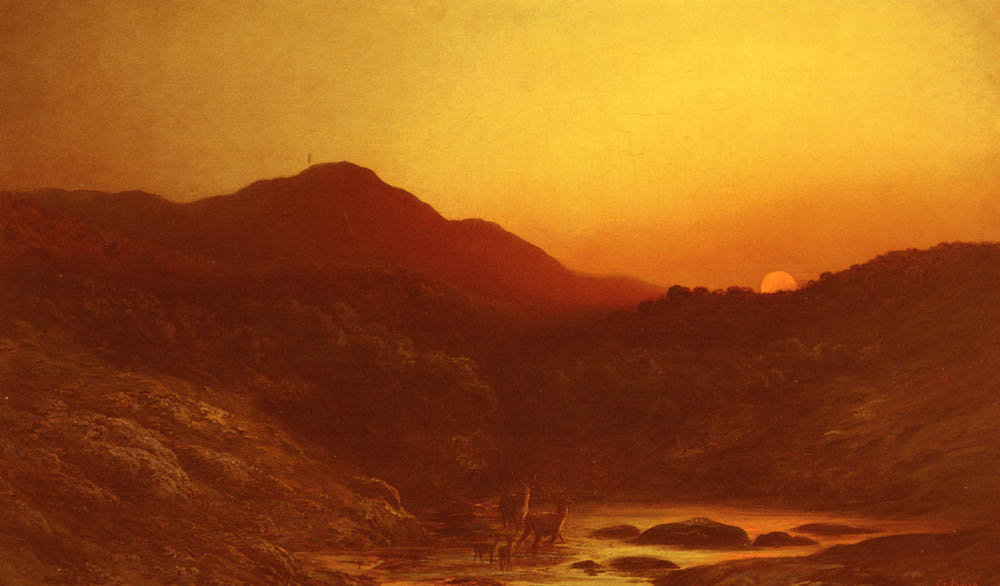
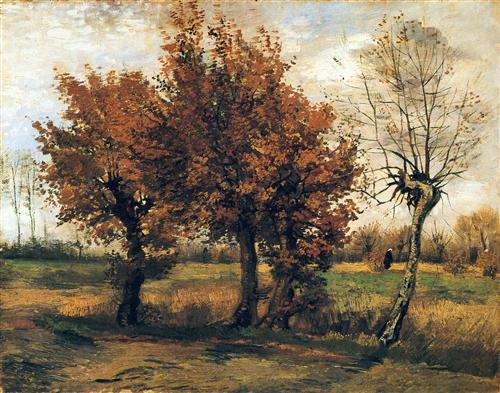
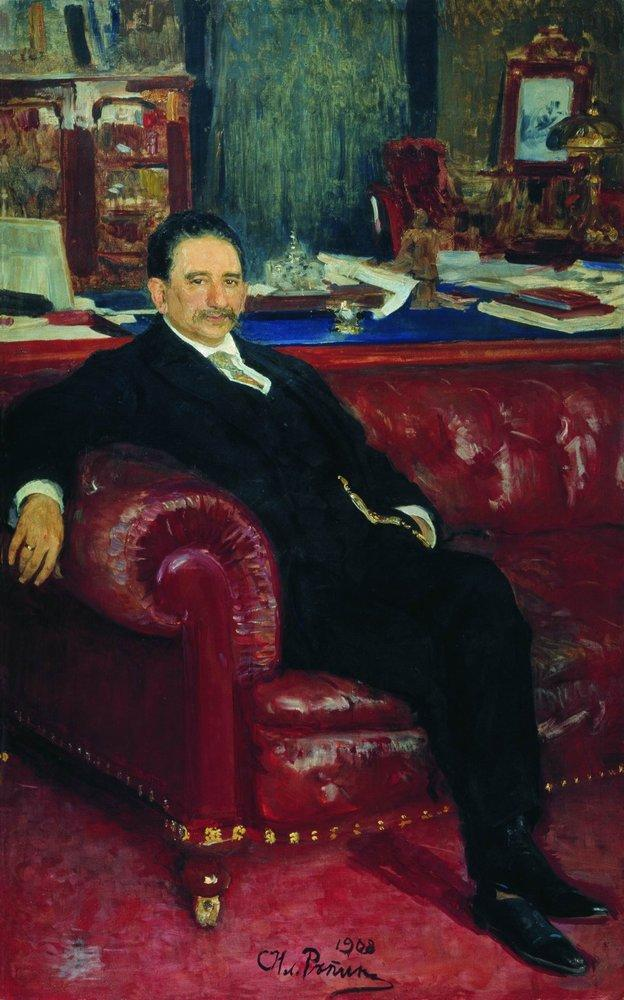
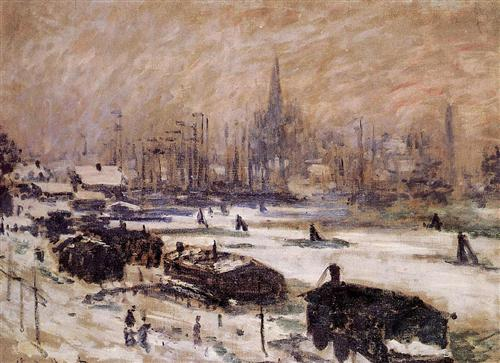
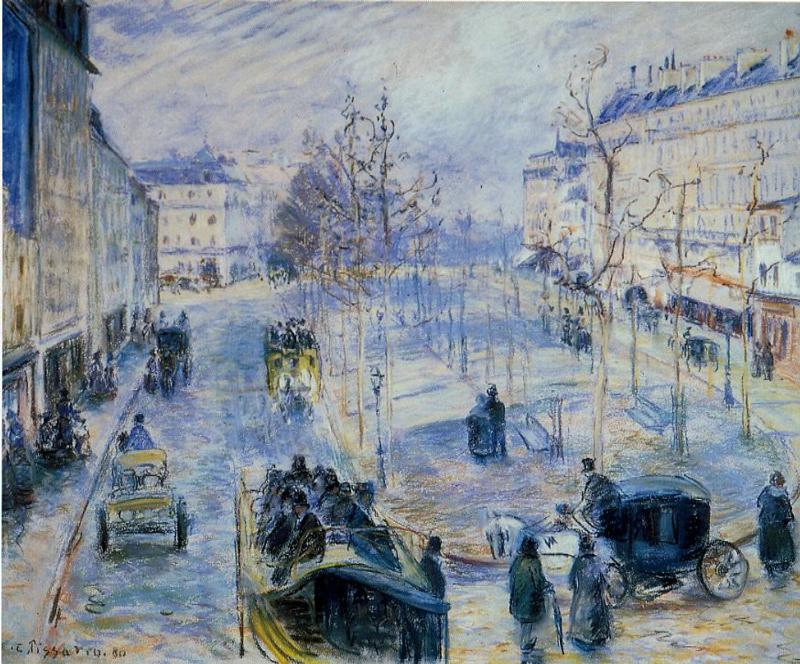
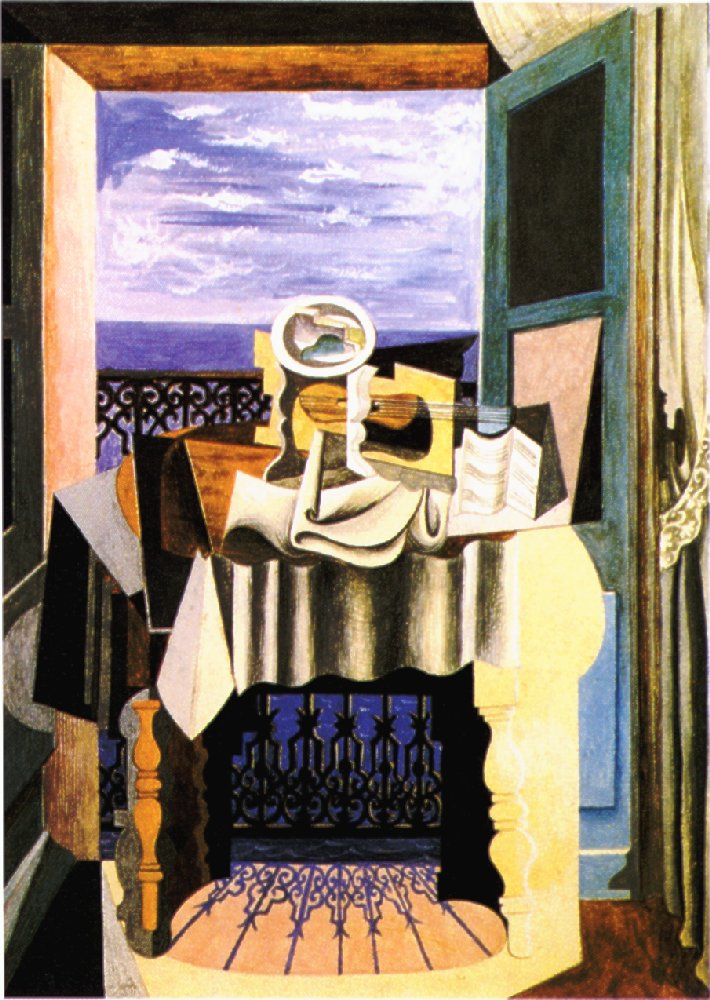

In [5]:
import base64

class HtmlDisplay(str):
    def _repr_html_(self):
        return str(self)

def image_tag(relative_path: str, width: int = 120) -> str:
    image_path = repo_root / 'data' / 'wikiart' / relative_path
    if not image_path.exists():
        return '<span style="color:#b00;">missing</span>'
    encoded = base64.b64encode(image_path.read_bytes()).decode('ascii')
    suffix = image_path.suffix.lower().lstrip('.') or 'jpeg'
    mime = 'image/jpeg' if suffix == 'jpg' else f'image/{suffix}'
    return f'<img src="data:{mime};base64,{encoded}" width="{width}" />'

review_template = df.loc[:32, [
    'rank_in_group',
    'image_path',
    'incorrect_tasks',
    'artist_true_name',
    'artist_pred_name',
    'mean_confidence',
    'verdict',
    'suggested_label',
    'notes',
]].copy()
review_template.insert(0, 'thumbnail', review_template['image_path'].map(image_tag))
HtmlDisplay(review_template.to_html(escape=False, index=False))